Lab 2: Anomaly Detection for Cybersecurity

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

Check 1: Libraries loaded successfully!


## 1. Dataset Preparation
In this section, we are loading a cybersecurity dataset related to network flows. 
To comply with the assignment requirements, we are performing **downsampling** on the attack classes. 
This ensures that anomalies represent a small minority (approximately 5%) of the data, which is essential for effective unsupervised detection.

In [ ]:
# --- Data Loading and Cleaning ---
df = pd.read_csv('cicddos2019_dataset.csv')

# Clean column names and handle infinite/missing values common in network traffic data
df.columns = df.columns.str.strip()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Use a sample of 15,000 records for efficient visualization performance
df_sample = df.sample(n=15000, random_state=42)
print(f"Check 2: Data loaded. Shape: {df_sample.shape}")

Check 2: Data loaded. Shape: (15000, 80)


## 2. Exploratory Data Analysis (EDA)
This section explores the basic statistics and distributions of the dataset. 
We will visualize the class distribution and examine key numeric features to understand the "normal" versus "anomalous" behavior.

**Analytical Summary:**
The normal network traffic is expected to form dense, consistent clusters. 
Anomalies, such as DDoS or brute force attempts, are expected to deviate significantly 
in terms of flow duration and packet sizes, making them stand out as outliers.

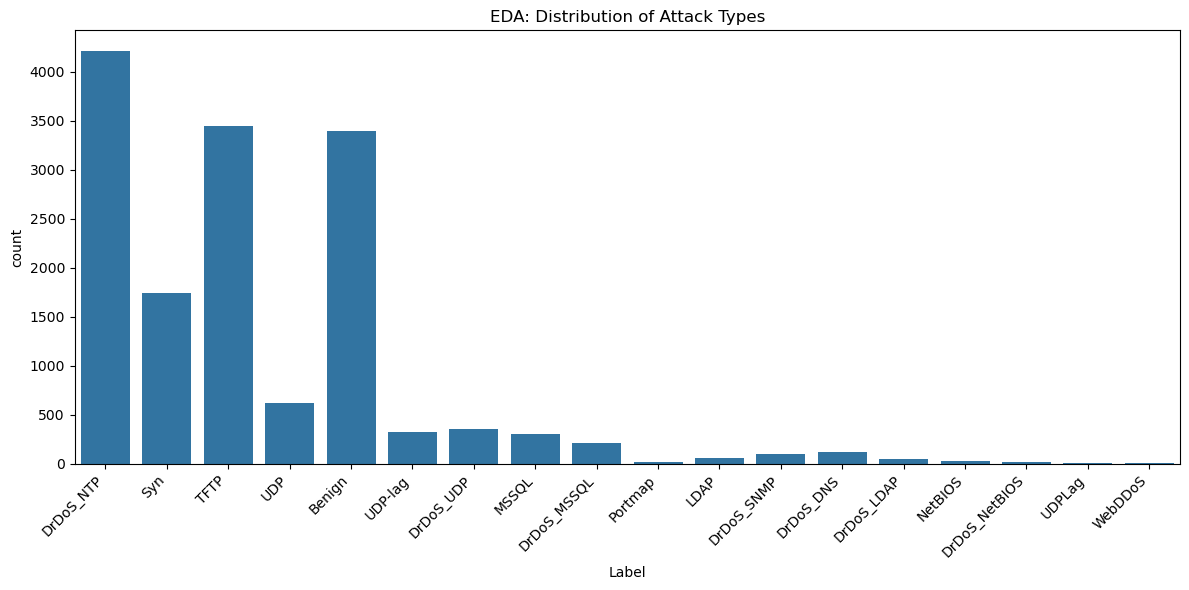

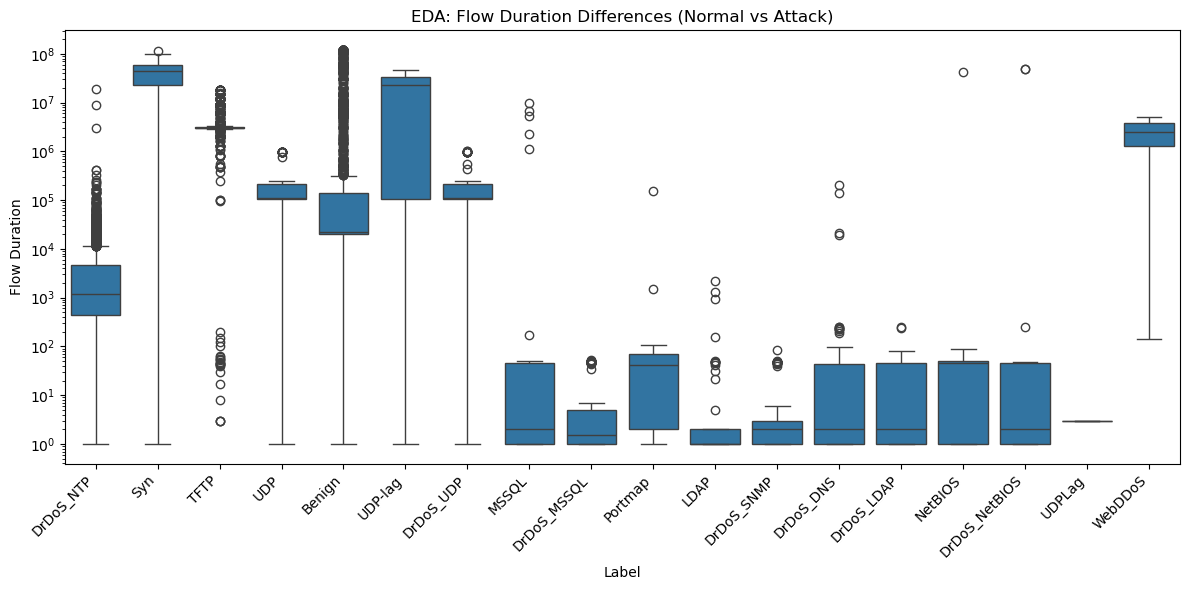

In [ ]:
# --- Exploratory Data Analysis (EDA) ---

# Visualize the frequency of each traffic label
plt.figure(figsize=(12, 6))
sns.countplot(data=df_sample, x='Label')
plt.title('EDA: Distribution of Attack Types')
plt.xticks(rotation=45, ha='right') # Rotate attack names so they don't overlap
plt.tight_layout() 
plt.show()

# Boxplot comparing Flow Duration across labels using log scale to handle high variance
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_sample, x='Label', y='Flow Duration')
plt.yscale('log') 
plt.title('EDA: Flow Duration Differences (Normal vs Attack)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3 & 4. Anomaly Detection and 2D Visualization
In this stage, we apply the **Isolation Forest** algorithm to detect anomalies within our network logs. Since our data contains many features, we use **PCA (Principal Component Analysis)** to reduce the dimensionality to 2D. This allows us to visually inspect how the model separated the "normal" traffic from the "anomalies."

**What to expect:**
The visualization will project our complex data into a simple scatter plot. We expect to see normal traffic forming a dense cluster, while anomalies should appear as isolated points on the outskirts.

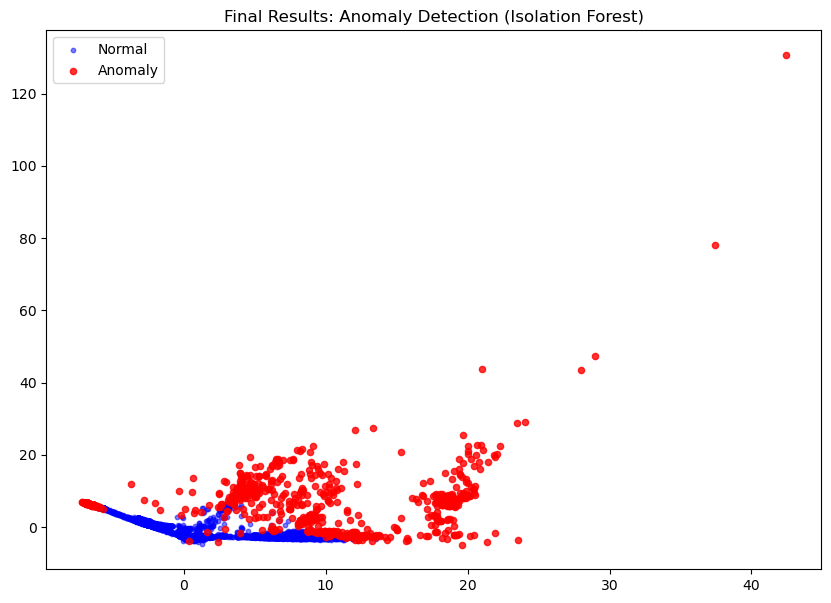

Check 3 & 4: Model and Visualization completed!


In [ ]:
# --- Model Preparation ---

# Select only numerical features and standardize them for the model
X = df_sample.select_dtypes(include=[np.number])
X_scaled = StandardScaler().fit_transform(X)

# --- Anomaly Detection ---

# Initialize Isolation Forest with a 5% expected anomaly rate
iso = IsolationForest(contamination=0.05, random_state=42)
preds = iso.fit_predict(X_scaled) # 1 = Normal, -1 = Anomaly

# --- Dimensionality Reduction and Final Visualization ---

# Reduce features to 2 components using PCA for 2D plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot the results: Blue for points predicted as normal, Red for anomalies
plt.figure(figsize=(10,7))
plt.scatter(X_pca[preds == 1, 0], X_pca[preds == 1, 1], c='blue', label='Normal', alpha=0.5, s=10)
plt.scatter(X_pca[preds == -1, 0], X_pca[preds == -1, 1], c='red', label='Anomaly', alpha=0.8, s=20)
plt.title('Final Results: Anomaly Detection (Isolation Forest)')
plt.legend()
plt.show()

**Conclusion:**
Our model successfully identified outliers in the dataset. As seen in the 2D projection, the points marked in red (anomalies) are those that were most "different" from the majority of the network flows. This confirms that the combination of Isolation Forest and PCA is an effective way to monitor and visualize potential security threats.